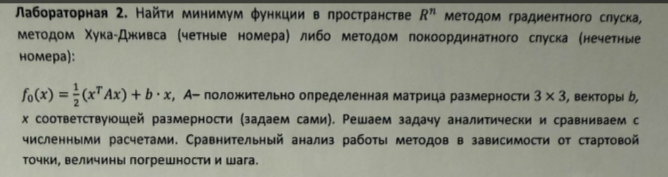

In [ ]:
import numpy as np

A = np.array([[4, 2, 0],
              [1, 3, 0],
              [1, 0, 2]], dtype=float)

b = np.array([1, 2, 7], dtype=float)
x0 = np.array([0, 0, 0], dtype=float)

A_sym = 0.5 * (A + A.T)

print(f"\nМатрица A:\n{A}")
print(f"\nВектор b: {b}")
print(f"Начальная точка x0: {x0}")
print(f"Размер шага: 0.1")
print(f"Точность: 1e-06")
print(f"\nСимметричная часть A_sym:")
print(A_sym)
print()


print("1. Аналитическое решение:")
x_analytic = np.linalg.solve(A_sym, -b)
print(f"Аналитическое решение: x* = {x_analytic}")

f_min = 0.5 * x_analytic @ A_sym @ x_analytic + b @ x_analytic
print(f"Минимальное значение функции: f(x*) = {f_min:.10f}\n")


def f(x):
    return 0.5 * x @ A_sym @ x + b @ x

def gradient(x):
    return A_sym @ x + b

def gradient_descent(x0, step_size=0.1, tol=1e-6, max_iter=10000):
    x = x0.copy()
    history = [x.copy()]
    i = 0
    for i in range(max_iter):
        grad = gradient(x)
        if np.linalg.norm(grad) < tol:
            break
        x = x - step_size * grad
        history.append(x.copy())
    return {'x': x, 'f': f(x), 'iterations': i + 1, 'history': history}

def hooke_jeeves(x0, step_size=0.1, tol=1e-6, max_iter=1000, alpha=2.0):
    x = x0.copy()
    x_base = x.copy()
    history = [x.copy()]
    n = len(x)
    current_step = step_size

    iteration = 0
    for iteration in range(max_iter):
        x_old = x_base.copy() # Запоминаем базовую точку начала итерации

        #  Исследующий поиск
        x_trial = x_base.copy()
        for i in range(n):
            e_i = np.zeros(n)
            e_i[i] = 1

            f_current = f(x_trial)
            f_plus = f(x_trial + current_step * e_i)
            f_minus = f(x_trial - current_step * e_i)

            if f_plus < f_current:
                x_trial = x_trial + current_step * e_i
            elif f_minus < f_current:
                x_trial = x_trial - current_step * e_i

        # Проверка успеха исследующего поиска
        if f(x_trial) < f(x_base):
            x_new = x_trial + alpha * (x_trial - x_base)

            if f(x_new) < f(x_trial):
                x_base = x_new
            else:
                x_base = x_trial
        else:
            current_step /= 2.0
            # Если шаг стал очень маленьким, останавливаемся
            if current_step < tol:
                break

            # Продолжаем поиск из текущей базовой точки (x_base не меняем)
            x = x_base

        x = x_base
        if np.linalg.norm(gradient(x)) < tol:
             break

        history.append(x.copy())

    return {'x': x, 'f': f(x), 'iterations': iteration + 1, 'history': history}


def compare_methods():
    print("\n2. Сравнение")

    gd_res = gradient_descent(x0, step_size=0.1, tol=1e-6)
    hj_res = hooke_jeeves(x0, step_size=0.1, tol=1e-6)

    print(f"\n{'Параметр':<20} | {'Градиентный спуск':<25} | {'Хук-Дживс':<25}")
    print("-"*72)
    print(f"{'Найденное решение':<20} | {str(gd_res['x']):<25} | {str(hj_res ['x']):<25}")
    print(f"{'Значение f(x)':<20} | {gd_res['f']:<25.10f} | {hj_res['f']:<25.10f}")
    print(f"{'Итераций':<20} | {gd_res['iterations']:<25} | {hj_res['iterations']:<25}")
    print(f"{'||x - x*||':<20} | {np.linalg.norm(gd_res['x'] - x_analytic):<25.2e} | {np.linalg.norm(hj_res['x'] - x_analytic):<25.2e}")

    # Проверка точности
    print("\nПроверка сходимости:")
    print(f"Градиентный спуск сошелся: {np.linalg.norm(gd_res['x'] - x_analytic) < 1e-4}")
    print(f"Хук-Дживс сошелся: {np.linalg.norm(hj_res['x'] - x_analytic) < 1e-4}")

def analyze_step_size():
    print("\n3. Зависимость от размера шага")
    steps = [0.001, 0.01, 0.05, 0.1, 0.2, 0.3]
    print(f"{'Шаг':<10} | {'Градиентный (итер)':<25} | {'Хук-Дживс (итер)':<25}")
    for s in steps:
        gd = gradient_descent(x0, step_size=s, tol=1e-6, max_iter=5000)
        hj = hooke_jeeves(x0, step_size=s, tol=1e-6, max_iter=5000)
        print(f"{s:<10.3f} | {gd['iterations']:<25} | {hj['iterations']:<25}")

def analyze_starting_point():
    print("\n4. Зависимость от начальной точки")
    starts = [
        np.array([0., 0., 0.]),
        np.array([5., 5., 5.]),
        np.array([10., -10., 10.])
    ]
    print(f"{'x0':<20} | {'Градиентный (итер)':<25} | {'Хук-Дживс (итер)':<25}")
    for x_start in starts:
        gd = gradient_descent(x_start, step_size=0.1, tol=1e-6)
        hj = hooke_jeeves(x_start, step_size=0.1, tol=1e-6)
        print(f"{str(x_start):<20} | {gd['iterations']:<25} | {hj['iterations']:<25}")

def main():
    # Проверка положительной определённости
    eigenvalues = np.linalg.eigvalsh(A_sym)
    print(f"Собственные значения A_sym: {eigenvalues}")
    print(f"Матрица положительно определена: {np.all(eigenvalues > 0)}\n")

    compare_methods()
    analyze_step_size()
    analyze_starting_point()

if __name__ == "__main__":
    main()


Матрица A:
[[4. 2. 0.]
 [1. 3. 0.]
 [1. 0. 2.]]

Вектор b: [1. 2. 7.]
Начальная точка x0: [0. 0. 0.]
Размер шага: 0.1
Точность: 1e-06

Симметричная часть A_sym:
[[4.  1.5 0.5]
 [1.5 3.  0. ]
 [0.5 0.  2. ]]

1. Аналитическое решение:
Аналитическое решение: x* = [ 0.56       -0.94666667 -3.64      ]
Минимальное значение функции: f(x*) = -13.4066666667

Собственные значения A_sym: [1.64267729 2.22323829 5.13408442]
Матрица положительно определена: True


2. Сравнение

Параметр             | Градиентный спуск         | Хук-Дживс                
------------------------------------------------------------------------
Найденное решение    | [ 0.55999973 -0.94666637 -3.63999963] | [ 0.56000061 -0.94666748 -3.64000092]
Значение f(x)        | -13.4066666667            | -13.4066666667           
Итераций             | 88                        | 48                       
||x - x*||           | 5.44e-07                  | 1.37e-06                 

Проверка сходимости:
Градиентный спуск сошелс